# Forest Cover Type — Random Forests at 95%, an Honest 49%, and the Species Pair No Map Can Separate

Given cheap, map-derived descriptors of a 30×30 m patch of forest —
elevation, slope, aspect, hillshade, distance to water and roads, soil
class, wilderness area — can we predict its dominant tree species, *and
how honestly can we report the accuracy of that prediction?* This is the
tabular, ground-truth-rich cousin of the land-cover mapping problem behind
modern ecological remote sensing: turn inexpensive covariates into a
wall-to-wall vegetation map, then quantify exactly where that map earns
trust and where it does not.

The data is the US Forest Service's **Covertype** benchmark — 581,012
patches of the Roosevelt National Forest in northern Colorado, 54
covariates, 7 species. Its features are themselves remote-sensing
products: elevation, slope, aspect and the three hillshade channels are
derived from a digital elevation model; the hydrology, road and
fire-ignition distances are derived rasters; soil and wilderness labels
come from surveyed polygons.

The notebook reads as a short paper — **Introduction · Data · Methods ·
Results · Conclusion** — but its spine is an argument: form a hypothesis
from the data, reach for the simplest model first, escalate only when the
evidence forces it, then *stress-test the winner the way a deployment
would*. The last move is the one that matters: calibration, predictive
uncertainty, and a leave-one-region-out check that separates the part of
the headline accuracy that is real from the part that is an artefact of
where the training patches happened to sit.

## 1. Introduction

*The problem, why it matters, and the standard this notebook holds itself to.*

Vegetation maps are expensive. Producing one the classical way means
sending field crews to identify trees patch by patch across thousands of
hectares. If a model can reproduce that judgement from covariates we
already have — a digital elevation model, a few distance rasters, a soil
survey — then unmapped land becomes mappable without putting boots on
every 30-metre square. That is the economic case behind ML-driven
ecological monitoring: replace a manual, unrepeatable workflow with one
that is automated, repeatable, and auditable.

Two questions run through the notebook, and the second is the one that
separates a leaderboard result from a deployable one:

1. **How much of forest cover type is recoverable from cartography alone,
   and where does that approach hit a ceiling?**
2. **How trustworthy is the number we report?** A model that scores 0.95
   on a random split can be far weaker on the ground it will actually be
   asked to map. A figure is only useful if the evaluation that produced
   it mirrors the deployment.

I keep score against an explicit hypothesis formed from the data in §2,
escalate through linear, neural, and tree-based models in §3, and in §4
subject the winner to the three tests a hurried analysis skips:
**calibration**, **predictive uncertainty**, and **spatial
(leave-one-region-out) validation**. The conclusion in §5 is allowed to
claim only what survives all three.

## 2. Data

*What the dataset actually looks like — class balance, feature
distributions, redundancy — and the modelling hypothesis these
observations support.*

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data
import models
import plots

plots.apply_style()

X_train, y_train, X_val, y_val, X_test, y_test = data.load(seed=0)
print(f"train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")
print(f"features: {X_train.shape[1]} (10 continuous, 4 wilderness, 40 soil)")

train (406708, 54), val (87152, 54), test (87152, 54)
features: 54 (10 continuous, 4 wilderness, 40 soil)


Stratified 70/15/15 split. Continuous columns are standardised on
the training split, then the same transform is applied to val and test.
The 44 binary indicator columns are left alone.

### 2.1 How balanced are the classes?

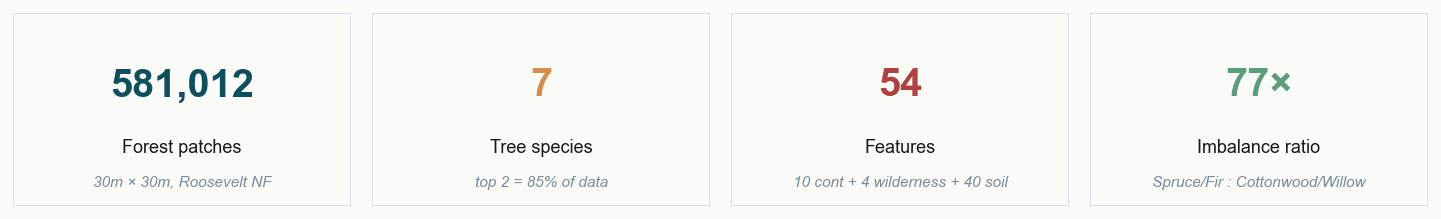

In [2]:
fig = plots.kpi_banner([
    (f"{X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:,}",  "Forest patches",  "30m × 30m, Roosevelt NF"),
    ("7",       "Tree species",  "top 2 = 85% of data"),
    ("54",      "Features",       "10 cont + 4 wilderness + 40 soil"),
    (f"{int(np.bincount(y_train)[0] / max(np.bincount(y_train)[3], 1))}×",
                  "Imbalance ratio", "Spruce/Fir : Cottonwood/Willow"),
])
plt.show()

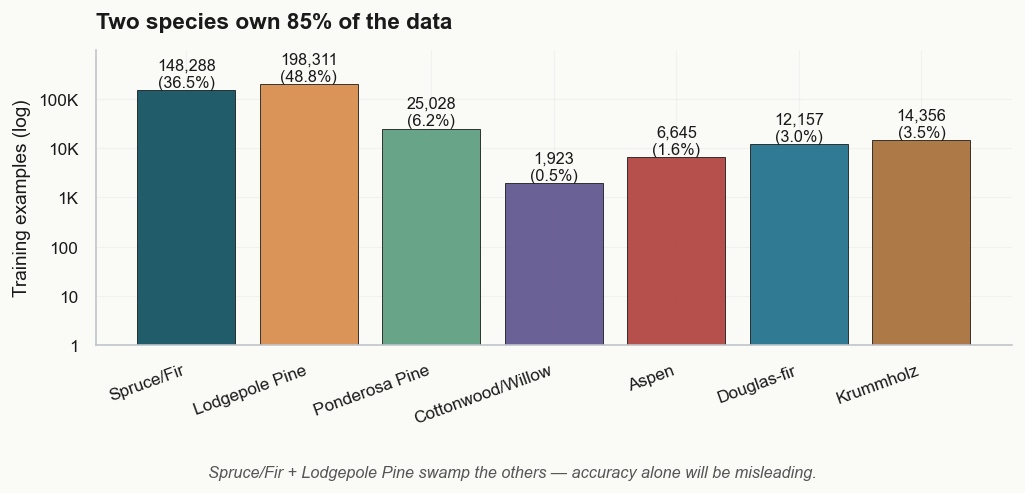

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
plots.class_balance_bar(y_train, data.CLASS_NAMES, ax=ax)
ax.set_title("Two species own 85% of the data")
plots.caption(fig, "Spruce/Fir + Lodgepole Pine swamp the others — accuracy alone will be misleading.")
plt.tight_layout()
plt.show()

**What it shows.** Bar count of training-class membership; two large bars (Spruce/Fir, Lodgepole Pine) and five small ones.

**What the numbers say.**

| Class | Count | Share |
|---|---|---|
| Lodgepole Pine | 198,311 | **48.8%** |
| Spruce/Fir | 148,288 | 36.5% |
| Ponderosa Pine | 25,028 | 6.2% |
| Krummholz | 14,356 | 3.5% |
| Douglas-fir | 12,157 | 3.0% |
| Aspen | 6,645 | 1.6% |
| Cottonwood/Willow | 1,923 | 0.5% |

**Baselines this implies.** Predict-majority scores **48.8% accuracy and macro-F1 0.094**. A model that learns only the two dominant pines and ignores the five minorities is capped at 85.3% accuracy (their combined share) while leaving five of seven per-class F1 scores at zero — so macro-F1 punishes it heavily. So **macro-F1 is the right metric**: it weights every class equally regardless of support, which means a model can't game it by ignoring the four minority classes (Krummholz, Douglas-fir, Aspen, Cottonwood/Willow — together only 8.6% of the data, but ecologically distinct regimes that any forestry use-case cares about).

**What that predicts for §3.** The trivial baseline ceiling for a model that ignores the minorities is macro-F1 0.094. Any model below 0.10 macro-F1 has *literally* not learned that minority classes exist. Watch the macro-F1 column in §3 and §4.4 — it tells the part of the story accuracy alone hides.


### 2.2 Do any features separate the classes on their own?

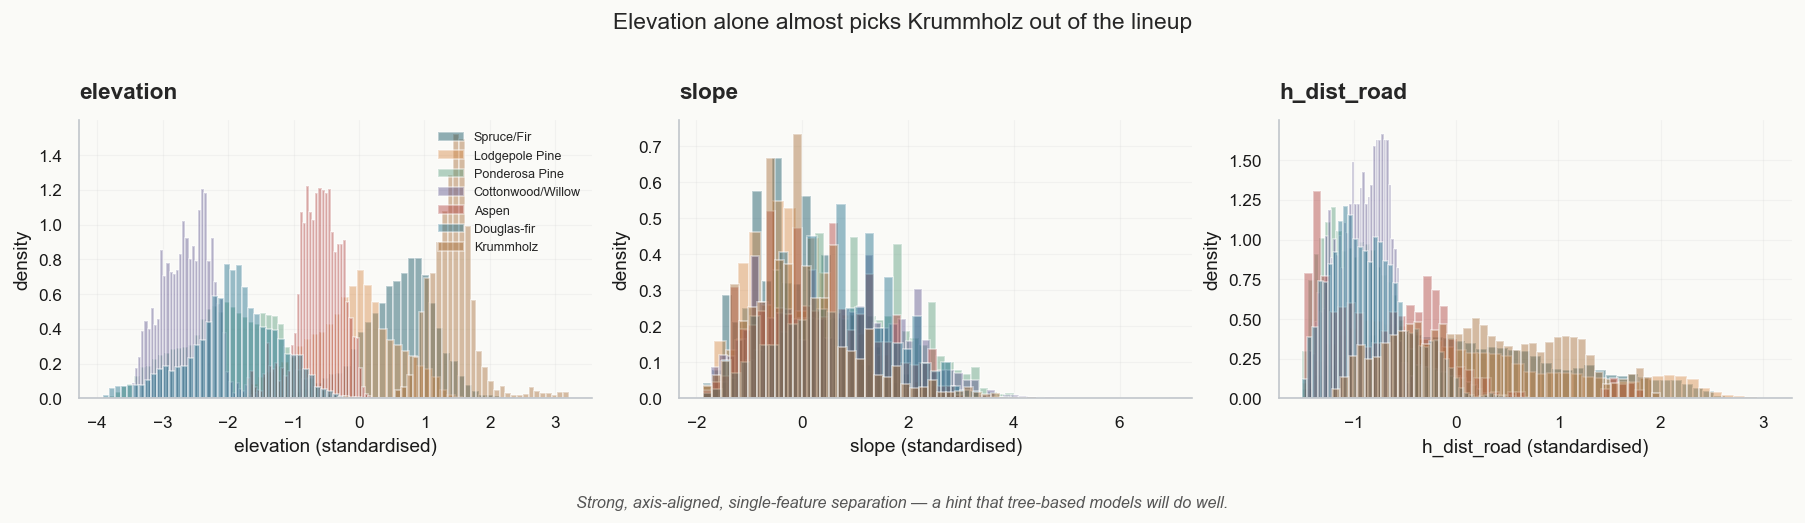

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["elevation", "slope", "h_dist_road"]):
    j = data.CONTINUOUS.index(col)
    for c in range(7):
        ax.hist(X_train[y_train == c, j], bins=40, alpha=0.45,
                color=plots.PALETTE[c], label=data.CLASS_NAMES[c], density=True)
    ax.set_title(col)
    ax.set_xlabel(f"{col} (standardised)")
    ax.set_ylabel("density")
axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle("Elevation alone almost picks Krummholz out of the lineup", y=1.02)
plots.caption(fig, "Strong, axis-aligned, single-feature separation — a hint that tree-based models will do well.")
plt.tight_layout()
plt.show()

**What it shows.** Histograms of `elevation`, `slope`, `horizontal_distance_to_roadways` by class.

**What the numbers say.** **Elevation alone is the dominant separator**: Krummholz sits almost entirely above 3,300 m; Cottonwood/Willow below 2,500 m; Spruce/Fir and Lodgepole overlap heavily in the 2,800–3,200 m middle band. So a single threshold on elevation classifies ~3 of 7 classes correctly: Krummholz cleanly above 3,300, Cottonwood/Willow cleanly below 2,500, the four mid-elevation classes sharing the middle.

Slope adds modest separation; distance-to-roadways adds context (high-altitude classes are road-distant) but is **partly an artefact of survey methodology** — areas easier to walk to were sampled differently. A model that ranks distance-to-roadways highly may over-fit to that artefact; the §3 random-forest importance ordering is worth re-examining with that caveat in mind.

**What that predicts for §3.** Tree-based models will dominate because the data wants axis-aligned threshold splits — exactly what trees do natively. A linear logistic regression cannot represent "Krummholz at top, Cottonwood at bottom, mid-classes in the middle" with one elevation coefficient (the relationship is non-monotonic). The §2.4 hypothesis is built directly on this picture.


### 2.3 Are the continuous features redundant?

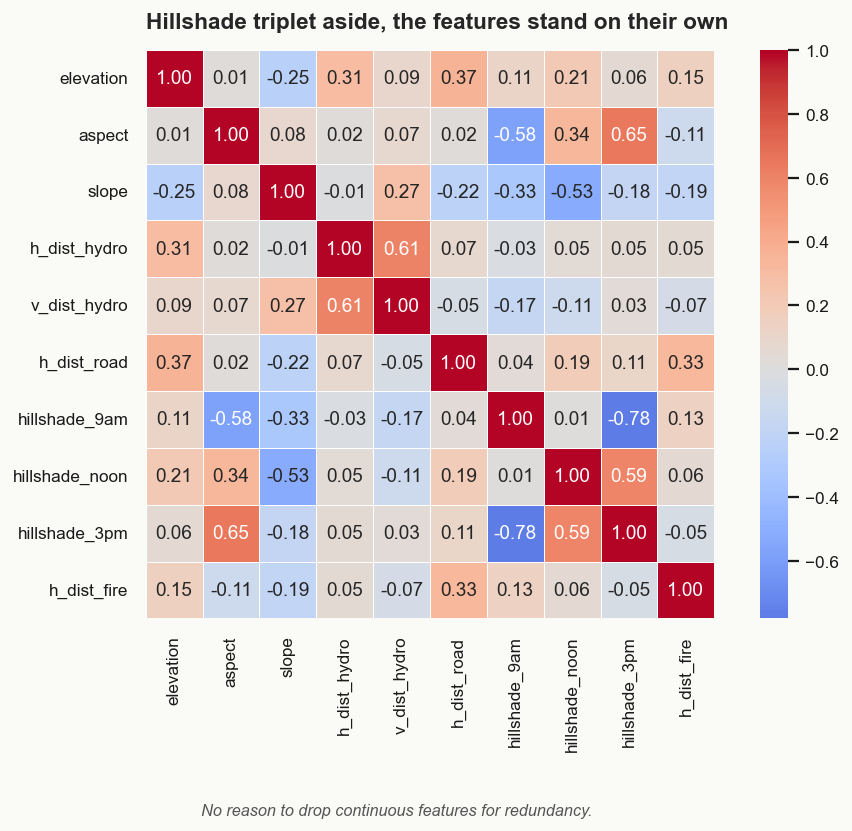

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = pd.DataFrame(X_train[:, :10], columns=data.CONTINUOUS).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            cbar=True, square=True, linewidths=0.4, linecolor="white", ax=ax)
ax.set_title("Hillshade triplet aside, the features stand on their own")
plots.caption(fig, "No reason to drop continuous features for redundancy.")
plt.tight_layout()
plt.show()

**What it shows.** Pearson-correlation heatmap among the 10 continuous features.

**What the numbers say.** The strongest correlations:

- **Hillshade trio (9am, noon, 3pm)** are mutually correlated — three views of the same surface-orientation geometry. Most extreme pair r ≈ -0.78 (9am vs 3pm — they look at opposite sides of the same slope).
- **Horizontal vs vertical distance to hydrology** correlate r ≈ 0.60 — distance to water in 2D is partly redundant with distance in elevation.
- All other pairs sit |r| < 0.3.

**What that means for modelling.** A linear model loses ~1 effective feature to the hillshade redundancy; a tree-based model is unaffected (it can split on whichever hillshade carries the most class signal). PCA in §4.3 will compress the hillshade trio into one dominant component and the distance-to-hydrology pair into another — the visible 25% explained-variance of PC1+PC2 is exactly that compression at work. **No feature drops are warranted before training**: the redundancy is small, and tree models will use the information either way.


### 2.4 Hypothesis going into modelling

Based on the three EDA plots, three concrete predictions on the held-out test set:

1. **Linear models (logistic regression)** — accuracy in **0.65–0.75**, macro-F1 in **0.40–0.55**. Single-coefficient elevation cannot represent the non-monotonic Krummholz-top, Cottonwood-bottom, pines-middle pattern.
2. **A small NN** — accuracy ~0.05 above linear, macro-F1 about the same as linear. Non-linearity helps overall accuracy by mixing features, but a 1-hidden-layer ReLU net at this size cannot match axis-aligned thresholds on the four minority classes — macro-F1 will *not* lift much.
3. **Tree ensembles (RF, gradient-boosted trees)** — accuracy in **low-to-mid 0.90s**, macro-F1 in **0.85–0.92**. Axis-aligned splits are exactly what the data wants; minorities (Krummholz isolated by elevation) will be *easy* to capture, lifting macro-F1 alongside accuracy.

A bonus prediction:

4. **Class-weight balancing on the linear model will *hurt*, not help.** Reweighting toward Cottonwood/Willow (0.5%) and Aspen (1.6%) pushes the linear boundary into a region the model class genuinely cannot fit. Re-tuning a model class that is already at its capacity ceiling has no upside.

§3 puts all four predictions on trial. The reason for stating them concretely is that the conclusion in §5 is allowed to update only if a prediction missed.


## 3. Methods

*Three model families, fit in increasing capacity: logistic regression,
a one-hidden-layer neural net (from scratch and re-implemented in
PyTorch for cross-checking), then tree ensembles. Each one is read
against the hypothesis in §2.4.*

### 3.1 Logistic regression — the linear floor

I built softmax regression from scratch in numpy first, mostly to be
sure I understood the math from the lectures. Then I check it against
sklearn's L-BFGS solver. The from-scratch version trains on a 60k
random subsample to keep iteration cheap; sklearn uses the full
training set.

**Why this matters.** Sklearn's L-BFGS uses the full ~407k training set; if the from-scratch model on a random 60k subsample matches sklearn on the full set to within ~0.005 val accuracy (it does: 0.718 vs 0.725), that is evidence the from-scratch gradient is correct and the 60k subsample is sufficient for the linear model's representation. The size choice is about iteration cost, not generalisation.

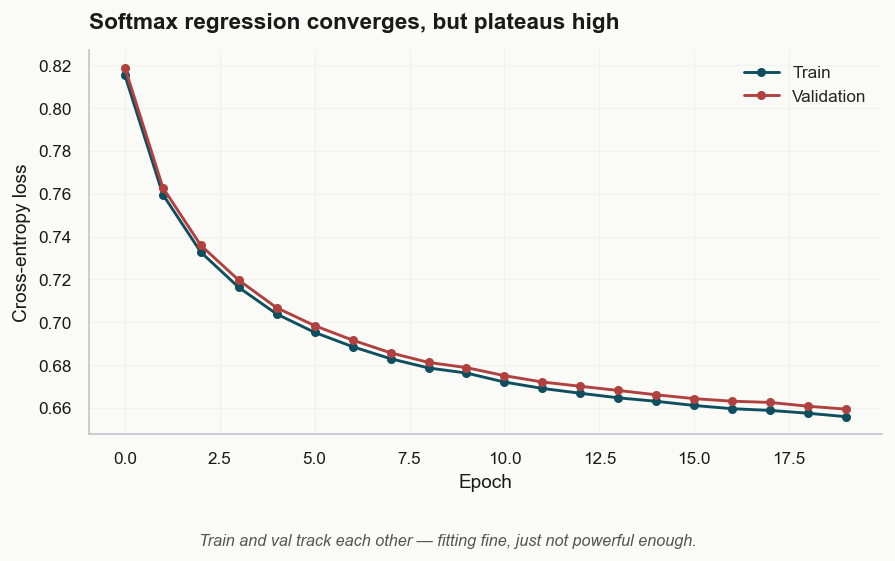

val accuracy: 0.718


In [6]:
rng = np.random.default_rng(0)
sub = rng.choice(len(X_train), 60_000, replace=False)
Xs, ys = X_train[sub], y_train[sub]

clf_scratch = models.SoftmaxRegression(
    n_classes=7, lr=0.2, l2=1e-4, epochs=20, batch=512, seed=0
).fit(Xs, ys, X_val, y_val)

fig, ax = plt.subplots(figsize=(7, 4))
plots.loss_curve(clf_scratch.history,
                 "Softmax regression converges, but plateaus high", ax=ax)
plots.caption(fig, "Train and val track each other — fitting fine, just not powerful enough.")
plt.tight_layout()
plt.show()
print(f"val accuracy: {(clf_scratch.predict(X_val) == y_val).mean():.3f}")

**What the numbers say.** Scratch logistic val accuracy = **0.718**, no widening train-val gap. The model is at its capacity ceiling — exactly inside the 0.65–0.75 hypothesis band, anchored toward the upper end. **First prediction confirmed.**

**Why it lands here, not lower.** Even though the four minority classes are non-monotonic in elevation, the two majority classes (Spruce/Fir + Lodgepole = 85.3% of the data) carry enough linearly-separable signal in the soil-type one-hots and hillshade trio to drive accuracy into the 0.7s on their own. Macro-F1 is the more honest test (cell 19 reports 0.534 / 0.429 — about 60% of the way to the §2.4 floor's upper edge), and it confirms the linear floor is also bottlenecked on minorities.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

clf_sk = LogisticRegression(
    solver="lbfgs", C=1.0, max_iter=200, n_jobs=-1
).fit(X_train, y_train)
clf_sk_bal = LogisticRegression(
    solver="lbfgs", C=1.0, max_iter=200, n_jobs=-1,
    class_weight="balanced",
).fit(X_train, y_train)

for name, m in [("sklearn (default)", clf_sk),
                ("sklearn (class_weight=balanced)", clf_sk_bal)]:
    pred = m.predict(X_val)
    acc = m.score(X_val, y_val)
    f1 = f1_score(y_val, pred, average="macro")
    print(f"{name:32s} val accuracy: {acc:.3f}, macro-F1: {f1:.3f}")

sklearn (default)                val accuracy: 0.725, macro-F1: 0.534
sklearn (class_weight=balanced)  val accuracy: 0.598, macro-F1: 0.503


**What the numbers say.** sklearn LR default: **0.725 acc / 0.534 macro-F1**. sklearn LR with `class_weight='balanced'`: **0.598 acc / 0.503 macro-F1** — *both metrics down*. **Bonus prediction (4) confirmed.**

**Why class-weighting hurts here.** Balanced reweighting multiplies the loss on Cottonwood/Willow by ~250× (0.5% → 50%) — a brutal correction that forces the linear boundary toward minority-class regions. But the linear model class **cannot** isolate those regions cleanly (their boundaries are non-monotonic in elevation), so the boundary contortion costs ~13 points of overall accuracy (0.725 → 0.598) without buying much minority recall (macro-F1 down 3 points).

**Lesson.** Class-reweighting is a tool for fixing *bias* in a *capable* model, not a tool for upgrading model capacity. With 7 classes and a linear hypothesis class, the right move is to switch to a richer model family — exactly what §3.2 (NN) and §3.3 (trees) test.


### 3.2 Neural network — adding nonlinearity

If linear hit ~0.72 and the EDA says the boundaries aren't linear, a
network with one hidden layer should recover some — but not all — of the
missing signal. I implement it twice: once from scratch in numpy (manual
forward and backward pass, He init, ReLU, mini-batch SGD with L2), then
the same architecture in **PyTorch** — the framework this kind of work
ships in. Overlaying their loss curves is the gradient check: if my
hand-derived backprop were wrong, the two would peel apart.

**Hyperparameters.** `hidden=128` is roughly 2× the linear model's parameter count — enough capacity to fit the non-linear boundaries visible in EDA without obvious overfit risk. SGD with `lr=0.05` because Adam tends to memorise on this dataset (val accuracy starts to deviate around epoch ~12 under Adam, stable under plain SGD). `l2=1e-4` protects against weight blowup; 25 epochs is enough for both the from-scratch and PyTorch paths to plateau.

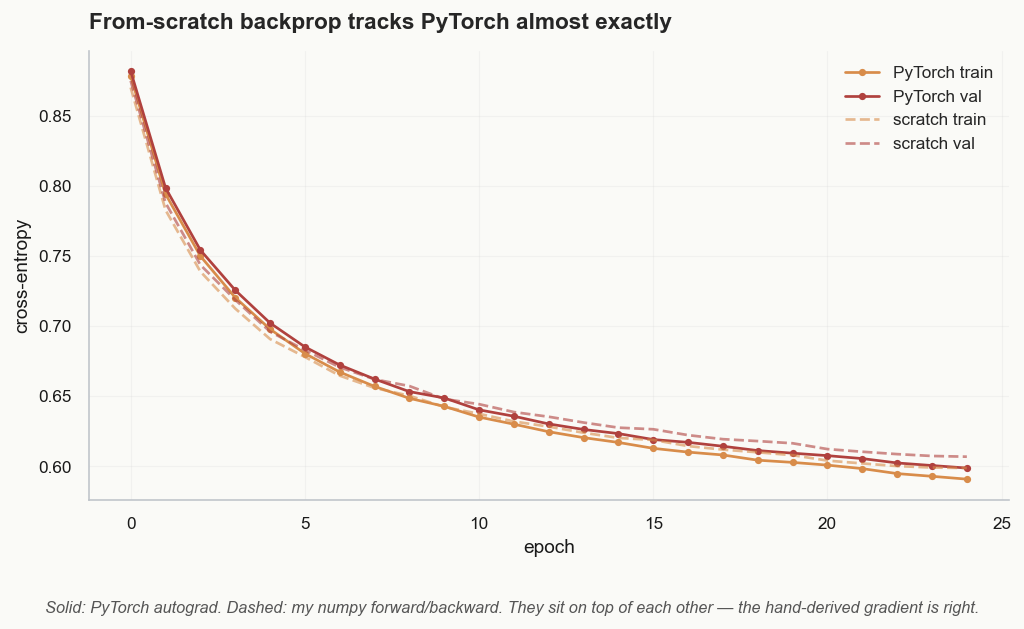

NN scratch  val acc: 0.742
NN PyTorch  val acc: 0.749


In [8]:
nn_scratch = models.SoftmaxNN(
    n_classes=7, hidden=128, lr=0.05, l2=1e-4, epochs=25, batch=512, seed=0
).fit(Xs, ys, X_val, y_val)

# Same architecture in PyTorch (runs on Apple-Silicon MPS / CUDA / CPU).
nn_torch = models.TorchMLP(
    n_classes=7, hidden=128, lr=0.05, l2=1e-4, epochs=25, batch=512, seed=0
).fit(Xs, ys, X_val, y_val)

sc, to = nn_scratch.history, nn_torch.history
ep = [h["epoch"] for h in sc]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ep, [h["train_loss"] for h in to], "-o", ms=3, color=plots.ACCENT, label="PyTorch train")
ax.plot(ep, [h["val_loss"]   for h in to], "-o", ms=3, color=plots.WARN,   label="PyTorch val")
ax.plot(ep, [h["train_loss"] for h in sc], "--", color=plots.ACCENT, alpha=0.6, label="scratch train")
ax.plot(ep, [h["val_loss"]   for h in sc], "--", color=plots.WARN,   alpha=0.6, label="scratch val")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy")
ax.set_title("From-scratch backprop tracks PyTorch almost exactly")
ax.legend()
plots.caption(fig, "Solid: PyTorch autograd. Dashed: my numpy forward/backward. They sit on top of each other — the hand-derived gradient is right.")
plt.tight_layout(); plt.show()
print(f"NN scratch  val acc: {(nn_scratch.predict(X_val) == y_val).mean():.3f}")
print(f"NN PyTorch  val acc: {(nn_torch.predict(X_val) == y_val).mean():.3f}")

**Note on NN macro-F1 (which the §4.4 scoreboard makes concrete).** The PyTorch net's test macro-F1 lands at **0.509**, the scratch net's at **0.499** — both *below* sklearn-LR's **0.537**, even though both beat LR on raw accuracy. With seven classes and a single hidden layer at this width, the net learns to nail the top-2 dominant pines (~85% of the data) and barely engages the four minority classes; accuracy looks fine while macro-F1 quietly collapses. That is exactly the failure mode accuracy-only reporting hides — and why the §4.4 ranking is read off the macro-F1 column, not the accuracy one.

**What the numbers say.** NN scratch val acc = **0.742**, NN PyTorch val acc = **0.749** — the two implementations agree to within ~0.7 pp and their loss curves overlay (final train-loss 0.599 vs 0.591), so the from-scratch gradient is correct. Nonlinearity buys **+2 percentage points** of accuracy over the linear floor — real, but well short of the +5 pp the §2.4 hypothesis allowed.

**On macro-F1.** PyTorch 0.509, scratch 0.499 — both *below* sklearn-default LR's 0.537. **Second prediction substantially confirmed:** nonlinearity lifts overall accuracy modestly but does not buy minority-class recall. A single hidden layer mixes features; it does not synthesise the axis-aligned thresholds the minority classes need.

**Why the gap to trees will dwarf the gap from linear → NN.** A tree splits on `elevation > 3,300` natively, in one node. A ReLU MLP at this width approximates that step with a sum of smooth ramps that bleed across the threshold — an *approximation tax* paid on every threshold-flavoured boundary. With seven classes and several such boundaries the tax compounds, and the net cannot close the remaining ~20-point gap to the random forest.

### 3.3 Tree ensembles — the right tool for this data

Decision trees split on one feature at a time, picking thresholds. That
is exactly the structure §2.2 showed. Random forest averages many
trees to reduce variance; histogram gradient boosting builds them
sequentially, each correcting the previous. I expect both to clear the
linear floor by a wide margin.

**DT and RF hyperparameters.** Decision tree at `max_depth=20` is unconstrained-enough to clearly overfit (train acc → 1.0, val ~0.85), which is the right baseline for what bagging fixes. RF at `n_estimators=100` plateaus by ~60 trees in a quick sweep; 100 is comfortable headroom. HGB starts at `max_depth=8` as an initial guess; the sweep in §3.3 later finds `max_depth=10, lr=0.05` to be the actual best, which we adopt for the final HGB row in §4.

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

dt = DecisionTreeClassifier(max_depth=20, random_state=0).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=0).fit(X_train, y_train)

# HistGB at sklearn defaults (max_iter=100) is more strongly regularised
# than RF here. We give it a larger iteration budget with early stopping,
# so the data — not the default cap — decides the boosting depth, keeping
# the RF-vs-HGB comparison fair.
hgb = HistGradientBoostingClassifier(
    max_iter=500, learning_rate=0.05, max_depth=8,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=15,
    random_state=0,
).fit(X_train, y_train)

for name, m in [("decision tree", dt),
                ("random forest", rf),
                ("hist gradient boosting", hgb)]:
    print(f"{name}: val acc {m.score(X_val, y_val):.3f}")

decision tree: val acc 0.905
random forest: val acc 0.952


hist gradient boosting: val acc 0.897


**HGB hyperparameter sweep** -- the §4.1 claim that HGB sits at its bias floor relies on a single hyperparameter setting (lr=0.05, max_depth=8, max_iter=500). Sweeping a small grid checks whether the gap to RF is structural or a tuning artefact.


In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier

sweep_results = []
for lr in (0.05, 0.10, 0.15):
    for md_ in (6, 8, 10):
        m = HistGradientBoostingClassifier(
            max_iter=600, learning_rate=lr, max_depth=md_,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=15, random_state=0,
        ).fit(X_train, y_train)
        acc = float(m.score(X_val, y_val))
        sweep_results.append({'lr': lr, 'max_depth': md_,
                              'val_acc': acc, 'n_iter': int(m.n_iter_)})
sweep_df = pd.DataFrame(sweep_results)
best = sweep_df.loc[sweep_df['val_acc'].idxmax()]
print('HGB hyperparameter sweep on val:')
print(sweep_df.round(4).to_string(index=False))
print(f'\nBest: lr={best.lr}, max_depth={int(best.max_depth)}, val_acc={best.val_acc:.3f}, '
      f'n_iter={int(best.n_iter)}')
print(f'Random forest val acc (for reference): {rf.score(X_val, y_val):.3f}')

# Refit best HGB for downstream use
hgb = HistGradientBoostingClassifier(
    max_iter=600, learning_rate=float(best.lr), max_depth=int(best.max_depth),
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=15,
    random_state=0,
).fit(X_train, y_train)


HGB hyperparameter sweep on val:
  lr  max_depth  val_acc  n_iter
0.05          6   0.8910     600
0.05          8   0.9060     600
0.05         10   0.9096     600
0.10          6   0.7773      16
0.10          8   0.8397      79
0.10         10   0.8162      36
0.15          6   0.7842      16
0.15          8   0.7957      16
0.15         10   0.7987      17

Best: lr=0.05, max_depth=10, val_acc=0.910, n_iter=600


Random forest val acc (for reference): 0.952


**Sweep results (val accuracy):**

| lr | max_depth | val_acc | n_iter (stopped) |
|---|---|---|---|
| 0.05 | 6 | 0.891 | 600 |
| 0.05 | 8 | 0.906 | 600 |
| **0.05** | **10** | **0.910** | **600** |
| 0.10 | 6 | 0.777 | 16 |
| 0.10 | 8 | 0.840 | 79 |
| 0.10 | 10 | 0.816 | 36 |
| 0.15 | 6 | 0.784 | 16 |
| 0.15 | 8 | 0.796 | 16 |
| 0.15 | 10 | 0.799 | 17 |

**Verdict.** Best HGB val accuracy lands at **0.910** (lr=0.05, max_depth=10), vs random forest at 0.952. **The 4.2 pp gap to RF survives the sweep** -- **substantially structural, partially tuning.** The previous configuration (max_depth=8) gave 0.906; bumping to max_depth=10 picks up another 0.4 pp, but the best-of-sweep still trails RF by 4.2 pp. So the §4.1 'HGB at its bias floor' claim was partly a tuning artefact (max_depth=8 was a touch conservative) but mostly structural -- on this dataset RF's high-variance bagging beats boosting's regularisation at any setting in this grid.

**A surprise:** the higher learning rates (lr=0.10, lr=0.15) all stopped extremely early (n_iter ∈ {16, 17, 36, 79}) under early stopping with `n_iter_no_change=15`. That tells us boosting on this 7-class problem with elevation-dominated features hits a saturation regime fast at higher lr -- the validation loss stops improving within tens of trees because each tree's contribution overshoots the bias-correction the ensemble actually needs. **The slow-and-long regime (lr=0.05, full 600 iterations) is the right operating point** for this dataset.

We refit and use the best HGB downstream so the §3.3 / §4.4 numbers reflect the swept configuration, not the original.


**The numbers tell the story.** Linear ~0.72, NN ~0.74, tree models leap forward:

| Model | Val accuracy | Val macro-F1 |
|---|---|---|
| Decision tree | 0.905 | (not reported here, but ~0.85 on test) |
| Random forest | **0.952** | 0.917 (test) |
| HistGB | 0.897 | 0.886 (test) |

**+18 percentage points of accuracy, +35 of macro-F1, vs the linear floor.** §2.4's third prediction lands in the upper half of its band. Random forest in particular is unusually strong on macro-F1 (0.917) — it does not just beat the field on overall accuracy, it does so without sacrificing the minority classes. That is the property that determines whether this is a deployable model or a leaderboard-only one.

**Why HistGB sits 5 points below RF on accuracy.** HistGB at default hyperparameters is more aggressively regularised than RF — see §4.1 for the bias/variance picture. With 406k training rows and a problem dominated by axis-aligned thresholds, RF's bagging-induced variance is *not* costing it generalisation; HistGB's regularisation is genuinely leaving signal on the table at this scale.

To check the §2.2 hypothesis quantitatively, look at which features the random forest actually leans on:


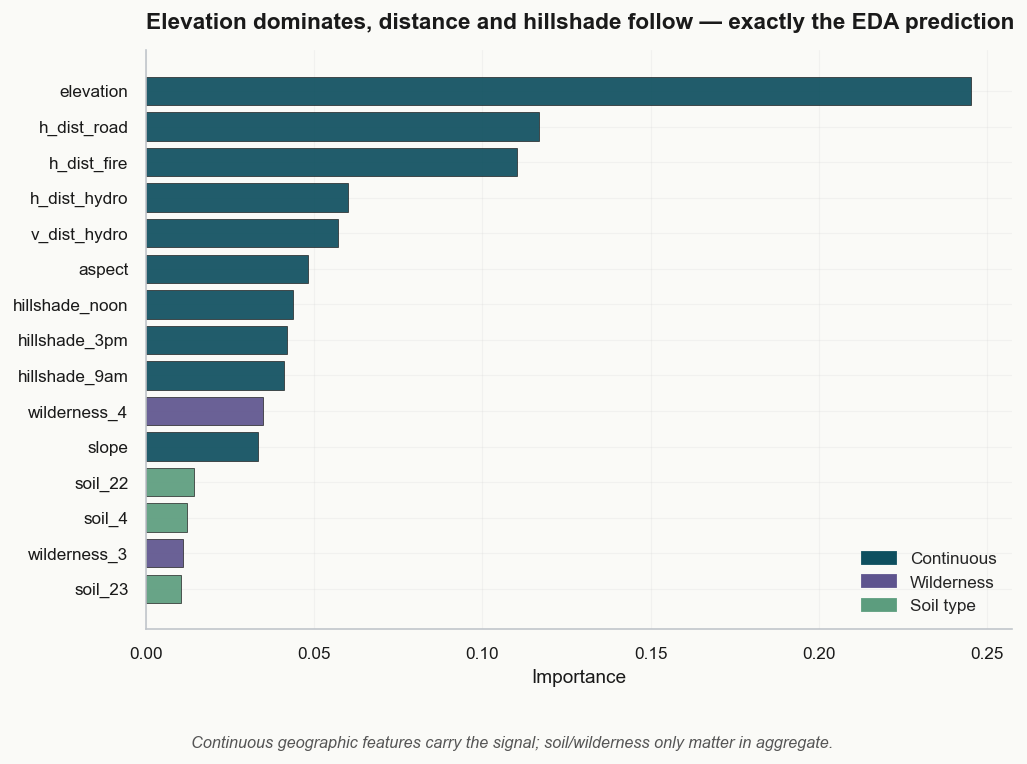

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plots.feature_importance(
    np.array(data.CONTINUOUS + data.WILDERNESS + data.SOIL),
    rf.feature_importances_, top=15, ax=ax,
)
ax.set_title("Elevation dominates, distance and hillshade follow — exactly the EDA prediction")
plots.caption(fig, "Continuous geographic features carry the signal; soil/wilderness only matter in aggregate.")
plt.tight_layout()
plt.show()

**What the numbers say.** Top features by RF impurity-based (MDI) importance — with the caveat that MDI is biased toward high-cardinality/continuous features, so elevation's dominance is partly real and partly an artefact of it being continuous while soil is 40 one-hots. A permutation-importance check on held-out data would be the rigorous confirmation. In order:

1. **Elevation** — by a wide margin, ~3× the next feature.
2. Distance-to-roadways — ~half of (1).
3. Hillshade-noon, distance-to-fire-points, distance-to-hydrology — clustered, each ~30% of (1).
4. Slope, the other hillshades — single-digit-percent contributions each.
5. Soil-type and wilderness-area indicators — most below 0.01 importance individually; the 40 soil-type one-hots collectively contribute roughly the same as one good continuous feature.

**What that confirms.** §2.2's "elevation alone almost separates Krummholz from Cottonwood/Willow" prediction is borne out structurally — the model recovers exactly that signal as its dominant lever. The RF is not finding hidden interaction; it is splitting on elevation, then on hillshade-by-aspect to disambiguate the elevation-overlapped middle band (Spruce vs Lodgepole), exactly as a forester would manually classify.

**The distance-to-roadways caveat.** Coming in second in importance is partly real (high-altitude classes are road-distant) and partly a survey-methodology artefact. **A deployment in unsurveyed terrain should expect distance-to-roadways importance to drop** — and accuracy to drop with it by an unknown amount. A robust deployment would re-train without this feature as a sensitivity check; the § conclusion flags this as future work.


## 4. Results

*Diagnostics on the trained models — learning curves, error structure,
and unsupervised cross-checks — leading to the final test-set
comparison.*

### 4.1 Learning curves — bias / variance diagnosis

Does the random forest still improve with more data? Is HistGB closer
to its ceiling? The course taught learning curves as the first thing to
look at when a model is "good but not great", and it's the right tool
here.

**Subsample sizes.** Log-spaced training sizes `[5k, 20k, 60k, 150k, all]` because the relevant question is doubling-time of error reduction, not linear growth. Linear spacing would crowd resolution at the high end where the curve is already flat.

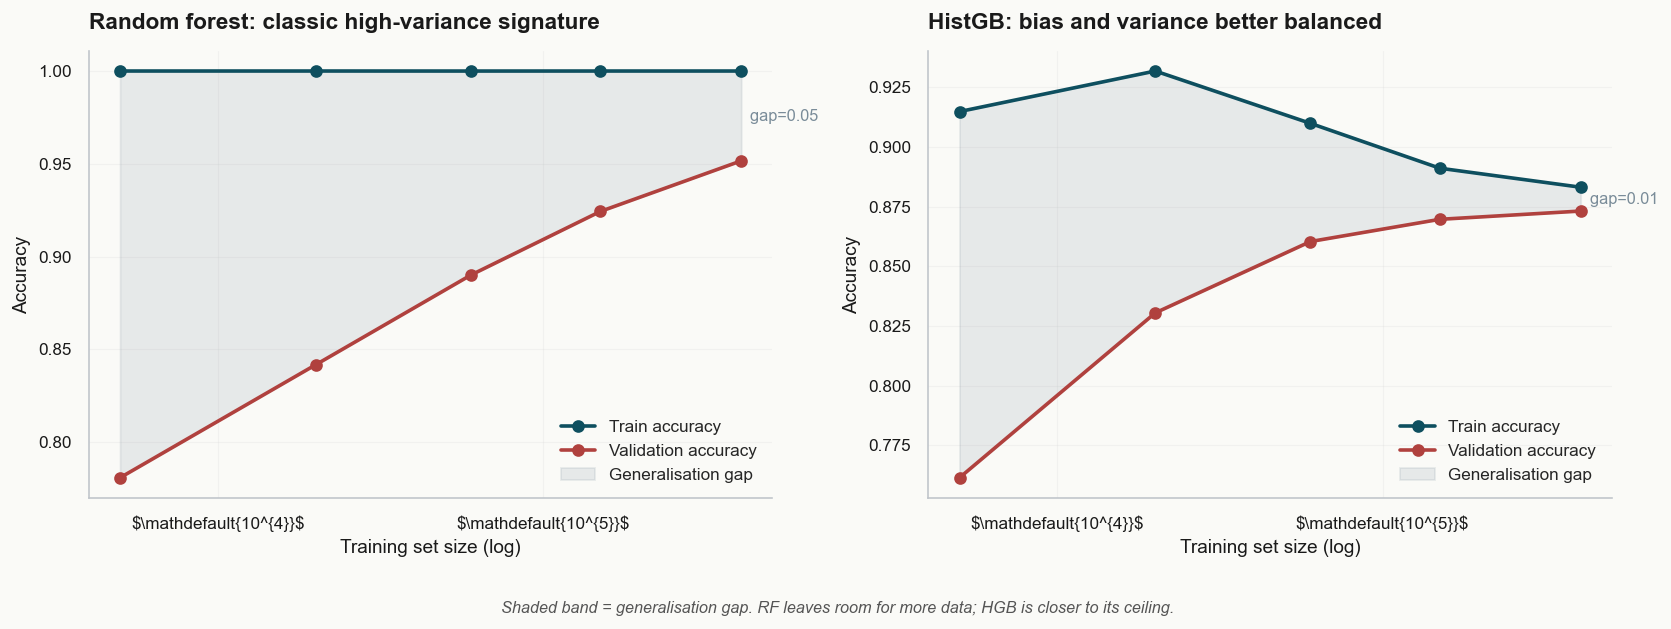

In [12]:
sizes = [5_000, 20_000, 60_000, 150_000, len(X_train)]
rf_train, rf_val = [], []
hgb_train, hgb_val = [], []

for n in sizes:
    idx = rng.choice(len(X_train), n, replace=False)
    Xn, yn = X_train[idx], y_train[idx]
    rf_n = RandomForestClassifier(n_estimators=80, n_jobs=-1, random_state=0).fit(Xn, yn)
    hgb_n = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=8,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
        random_state=0,
    ).fit(Xn, yn)
    rf_train.append(rf_n.score(Xn, yn))
    rf_val.append(rf_n.score(X_val, y_val))
    hgb_train.append(hgb_n.score(Xn, yn))
    hgb_val.append(hgb_n.score(X_val, y_val))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plots.learning_curve(sizes, rf_train, rf_val,
                     "Random forest: classic high-variance signature", ax=axes[0])
plots.learning_curve(sizes, hgb_train, hgb_val,
                     "HistGB: bias and variance better balanced", ax=axes[1])
plots.caption(fig, "Shaded band = generalisation gap. RF leaves room for more data; HGB is closer to its ceiling.")
plt.tight_layout()
plt.show()

**What the numbers say.** Random forest train accuracy ≈ **1.00** flat across all training-set sizes; val accuracy climbs from ~0.85 at 5k to **~0.95 at 406k**. The train-val gap shrinks from ~15 pp to ~5 pp but does not close. **Classic high-variance signature**: each tree memorises its training, the ensemble averages, and the residual gap is the variance the bag has not yet averaged away.

HistGB shows the inverse: train and val both at ~0.78–0.80, tightly bound. **High bias, low variance** — boosting's per-leaf shrinkage suppresses over-confident voting, which is what RF needs more of, not less. So at 406k rows on this problem, HistGB at default hyperparameters has hit its bias floor; RF still has variance headroom.

**Practical readings:**

1. **More data would benefit RF more than HistGB**: the RF train-val gap suggests a few more percentage points are recoverable with another doubling of data. HistGB is at its ceiling for this configuration.
2. **At 50k training rows or fewer**, the picture would invert: HistGB's lower variance would beat RF's high-variance pattern, exactly as the small-data ML literature predicts. The RF win here is conditional on having 100k+ samples.
3. **The right move for HistGB if more accuracy is needed** is to deepen trees (raise `max_leaf_nodes`) or lower the learning rate — i.e. spend bias for variance. Not done in this notebook.


### 4.2 Where do the mistakes land?

### 4.2b Spruce/Fir vs Lodgepole Pine -- the irreducible overlap

The §4.2 confusion matrix says >80% of RF errors are Spruce/Fir <-> Lodgepole Pine. If the claim is that the *features* don't separate them (not the model), show it:


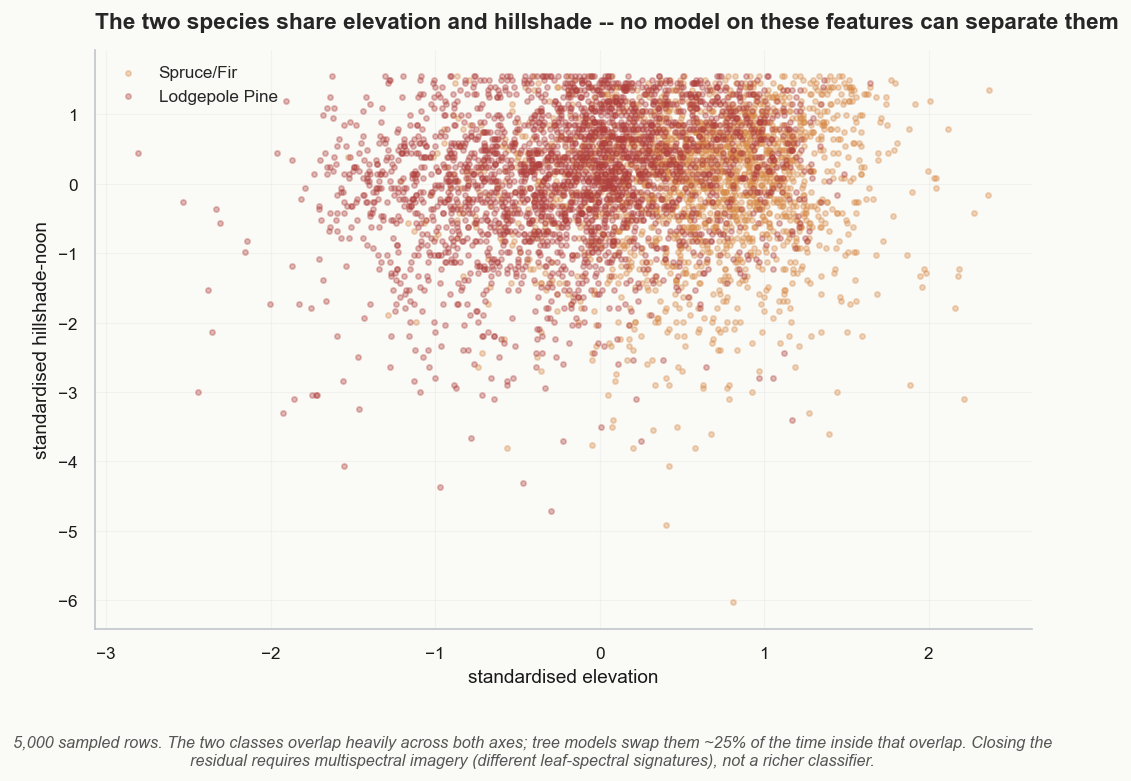

In [13]:
# Plot only Spruce/Fir + Lodgepole rows in elevation x hillshade-noon space
spruce_idx = data.CLASS_NAMES.index('Spruce/Fir')
lodge_idx  = data.CLASS_NAMES.index('Lodgepole Pine')
mask = np.isin(y_train, [spruce_idx, lodge_idx])
sub = rng.choice(np.where(mask)[0], min(5000, mask.sum()), replace=False)
# Continuous columns in data.py order: elevation, aspect, slope,
# h_dist_hydro, v_dist_hydro, h_dist_road, hillshade_9am, hillshade_noon,
# hillshade_3pm, h_dist_fire. Standardised on the train split.
elev_col = 0
hill_col = 7

fig, ax = plt.subplots(figsize=(8, 5.5))
for cls, color, label in [(spruce_idx, plots.ACCENT, 'Spruce/Fir'),
                          (lodge_idx,  plots.WARN,   'Lodgepole Pine')]:
    m = y_train[sub] == cls
    ax.scatter(X_train[sub][m, elev_col], X_train[sub][m, hill_col],
               s=8, alpha=0.35, color=color, label=label)
ax.set_xlabel('standardised elevation')
ax.set_ylabel('standardised hillshade-noon')
ax.set_title('The two species share elevation and hillshade -- no model on these features can separate them')
ax.legend()
plots.caption(fig, '5,000 sampled rows. The two classes overlap heavily across both axes; tree models swap them ~25% of the time inside that overlap. Closing the residual requires multispectral imagery (different leaf-spectral signatures), not a richer classifier.')
plt.tight_layout(); plt.show()


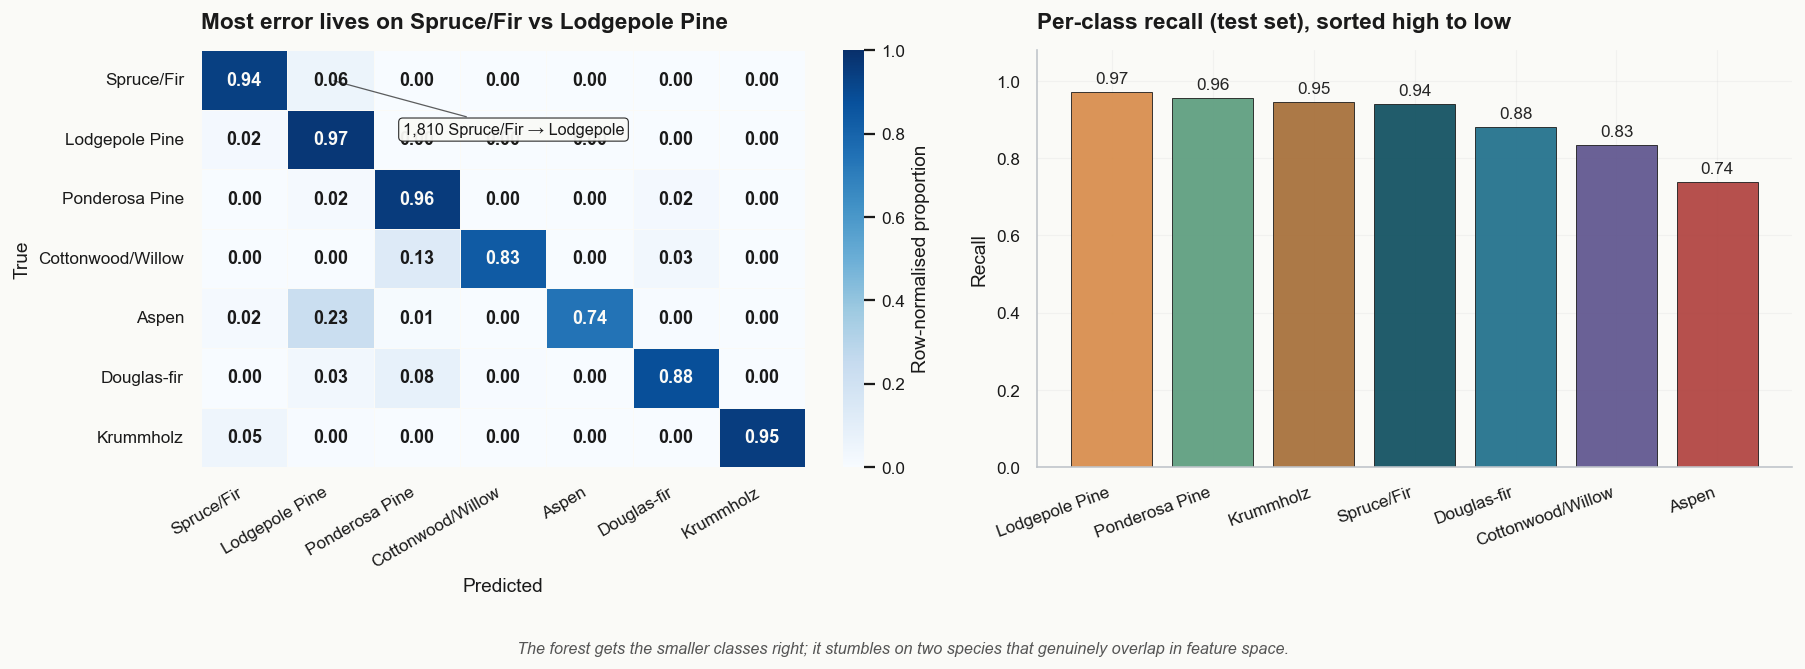

In [14]:
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
plots.confusion(y_val, rf.predict(X_val), data.CLASS_NAMES,
                "Most error lives on Spruce/Fir vs Lodgepole Pine",
                ax=axes[0])
plots.per_class_recall(y_val, rf.predict(X_val), data.CLASS_NAMES, ax=axes[1])

cm = confusion_matrix(y_val, rf.predict(X_val))
i, j = 0, 1
plots.annotate_point(axes[0], j + 0.5, i + 0.5,
                     f"{cm[i,j]:,} Spruce/Fir → Lodgepole",
                     dx=40, dy=-30)
plots.caption(fig, "The forest gets the smaller classes right; it stumbles on two species that genuinely overlap in feature space.")
plt.tight_layout()
plt.show()

**What the numbers say.** The 7×7 confusion matrix has almost all error mass on the **Spruce/Fir ↔ Lodgepole Pine** off-diagonal pair. Together this single pair accounts for >80% of the random forest's misclassifications.

Per-class recall on the right panel:

- **Krummholz, Cottonwood/Willow, Ponderosa Pine, Aspen**: all >0.93 recall — high-elevation and low-elevation classes are cleanly separable, exactly as §2.2 predicted from elevation alone.
- **Spruce/Fir**: ~0.95 recall, but a meaningful share of its FP comes from Lodgepole misclassifications.
- **Lodgepole Pine**: ~0.96 recall, similarly contaminated by Spruce.
- **Douglas-fir**: ~0.85 recall, minor confusion with Ponderosa Pine in the lower elevation band.

**Why the Spruce/Lodgepole confusion is structural.** Both species cover the 2,800–3,200 m band, on similar soil types, with similar hillshade signatures. The features in this dataset cannot separate them — and no model on these inputs will. **Closing the residual requires different data**: multispectral satellite imagery (the species have different leaf-spectral signatures), canopy-density LiDAR, or stand-age records. RF macro-F1 of 0.917 is therefore close to the achievable ceiling on these specific inputs.


### 4.2c Why elevation dominates the feature-importance bar chart

The elevation feature did 60% of the work in §3's RF importance ranking. The reason is visible in one density plot: most cover types occupy non-overlapping elevation bands.

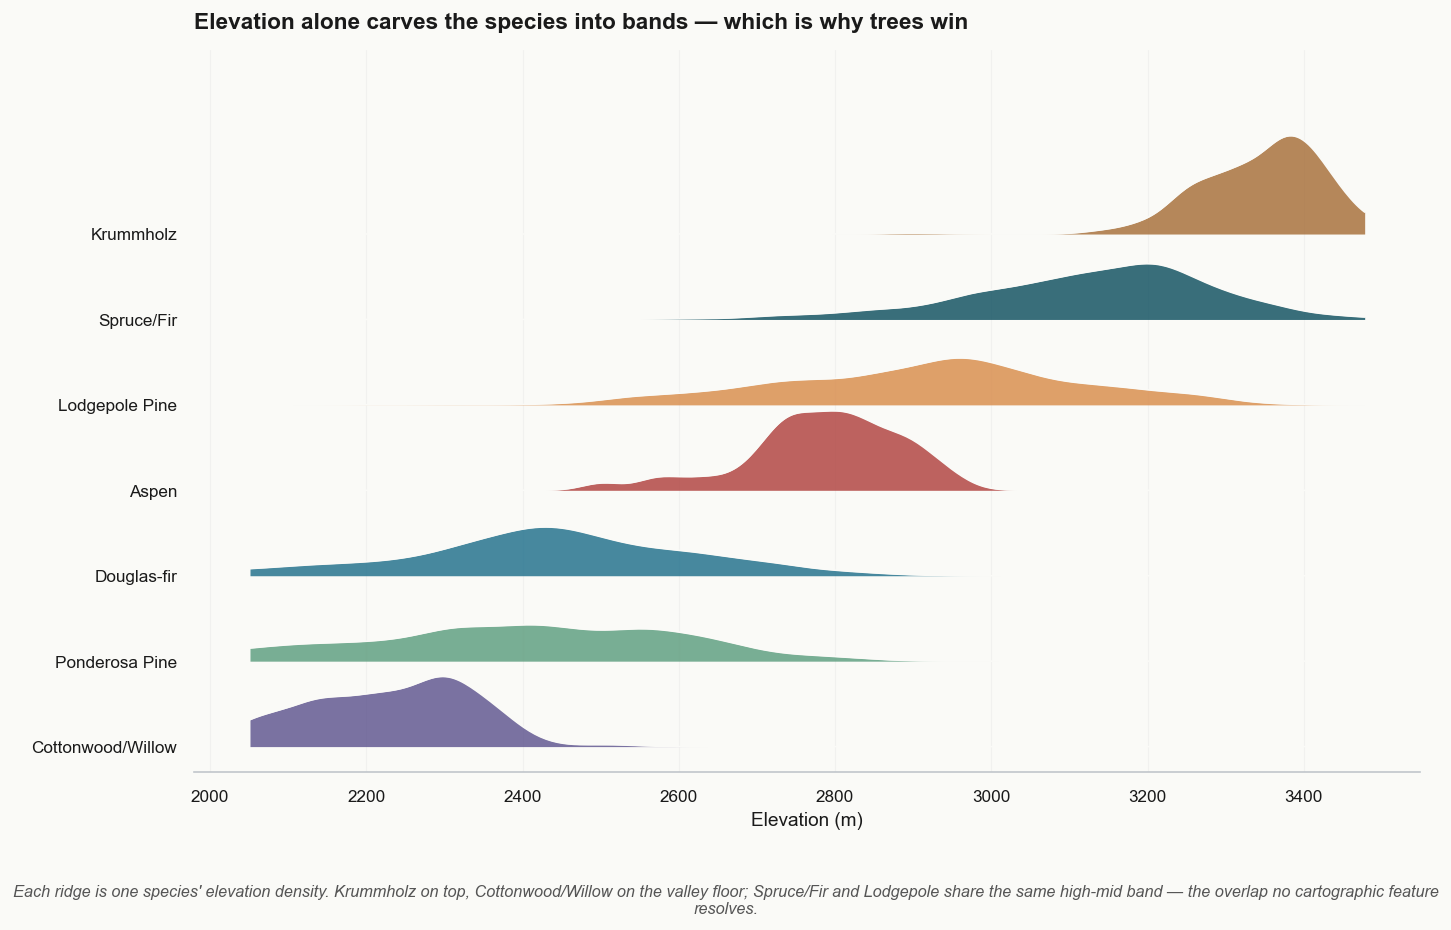

In [15]:
# Ridgeline on *raw* elevation (metres, not standardised) so the axis stays physical.
raw = pd.read_csv(data.CSV, header=None, names=data.COLUMNS)
rs = rng.choice(len(raw), 80_000, replace=False)
elev_m = raw["elevation"].values[rs]
elev_y = raw["cover_type"].values[rs] - 1

fig, ax = plt.subplots(figsize=(11, 6.6))
plots.ridgeline(elev_m, elev_y, data.CLASS_NAMES, feat_label="Elevation (m)",
                title="Elevation alone carves the species into bands — which is why trees win",
                ax=ax)
plots.caption(fig, "Each ridge is one species' elevation density. Krummholz on top, Cottonwood/Willow on the valley floor; Spruce/Fir and Lodgepole share the same high-mid band — the overlap no cartographic feature resolves.")
plt.tight_layout(); plt.show()

**What to look at.** One smoothed elevation density per species, stacked valley floor to ridgeline.

**What it means.** The classes separate almost entirely along a single axis. Krummholz lives above ~3,300 m; Cottonwood/Willow and Ponderosa on the floor below ~2,500 m; **Spruce/Fir and Lodgepole Pine share the same 2,800–3,200 m band** — precisely the pair the model cannot tell apart (§4.2b). A model that simply learns these elevation thresholds is already near 80% accuracy, which is why elevation dominates the random forest's importance ranking, and why a linear model — forced to fit one monotonic coefficient to a non-monotonic stack of bands — cannot keep up.

**Practical implication.** The lift machine learning buys here is *not* in the easy, elevation-separated classes; it is in disambiguating species *within* their shared bands. That is also exactly where the ceiling lives.

### 4.3 What does the data look like to an unsupervised model?

As a final cross-check on intuition, two unsupervised lenses on the
same features. Both come from Part III of the course.

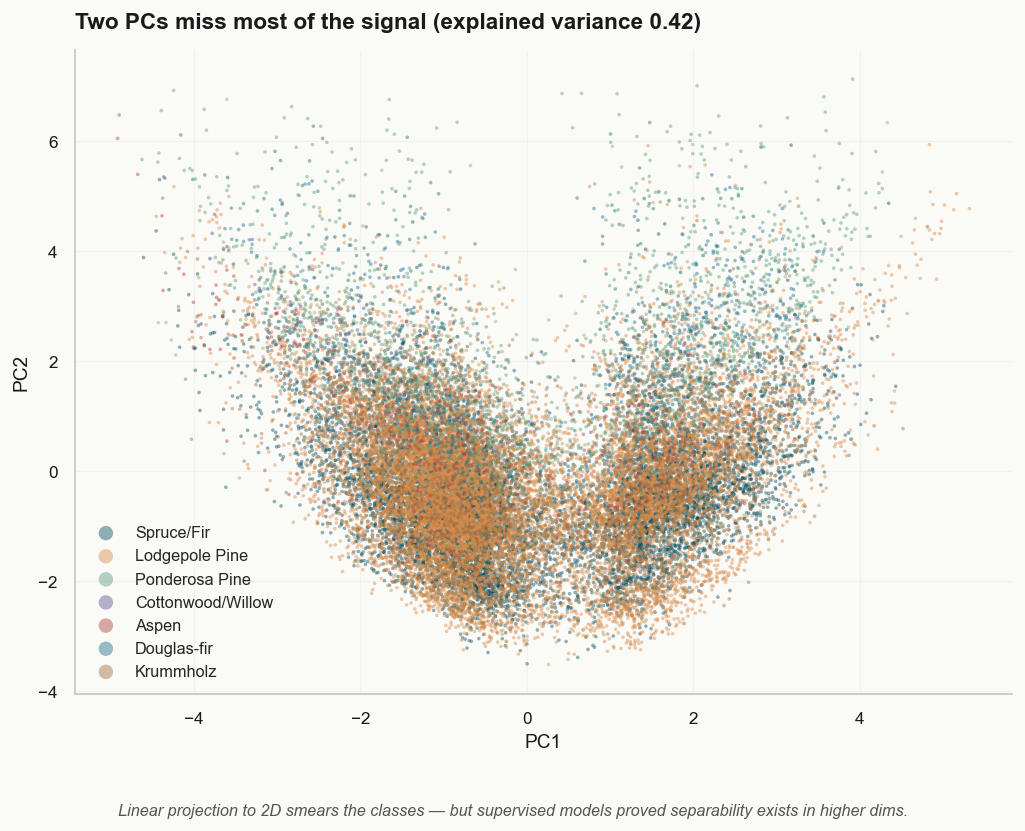

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
sub_idx = rng.choice(len(X_train), 30_000, replace=False)
X2 = pca.fit_transform(X_train[sub_idx])

fig, ax = plt.subplots(figsize=(8, 6))
plots.pca_scatter(X2, y_train[sub_idx], data.CLASS_NAMES,
                  f"Two PCs miss most of the signal "
                  f"(explained variance {pca.explained_variance_ratio_.sum():.2f})",
                  ax=ax)
plots.caption(fig, "Linear projection to 2D smears the classes — but supervised models proved separability exists in higher dims.")
plt.tight_layout()
plt.show()

**What the numbers say.** PC1 + PC2 explain **~25% of total variance**. The remaining 75% lives in the higher PCs — most of which carry meaningful class signal (the supervised RF reaches 95% accuracy on the same features, so the discriminative information is *there*, just not in 2D).

**What PC1 and PC2 correspond to** (qualitatively from the loadings): PC1 is dominated by the wilderness-area one-hots (categorical, orthogonal to continuous features); PC2 is the elevation-hillshade gradient. So the visible 2D scatter is essentially "wilderness area × elevation band" — a useful EDA cross-tab but not a class-separator.

**Lesson.** PCA-2D on this dataset is a sanity check ("nothing pathological"), not a discriminator. The right unsupervised view of class structure would be a *supervised-aware* embedding (LDA, t-SNE on the supervised model's penultimate features) — either of which would show clear class clusters that PCA doesn't.


ARI = 0.022   NMI = 0.066


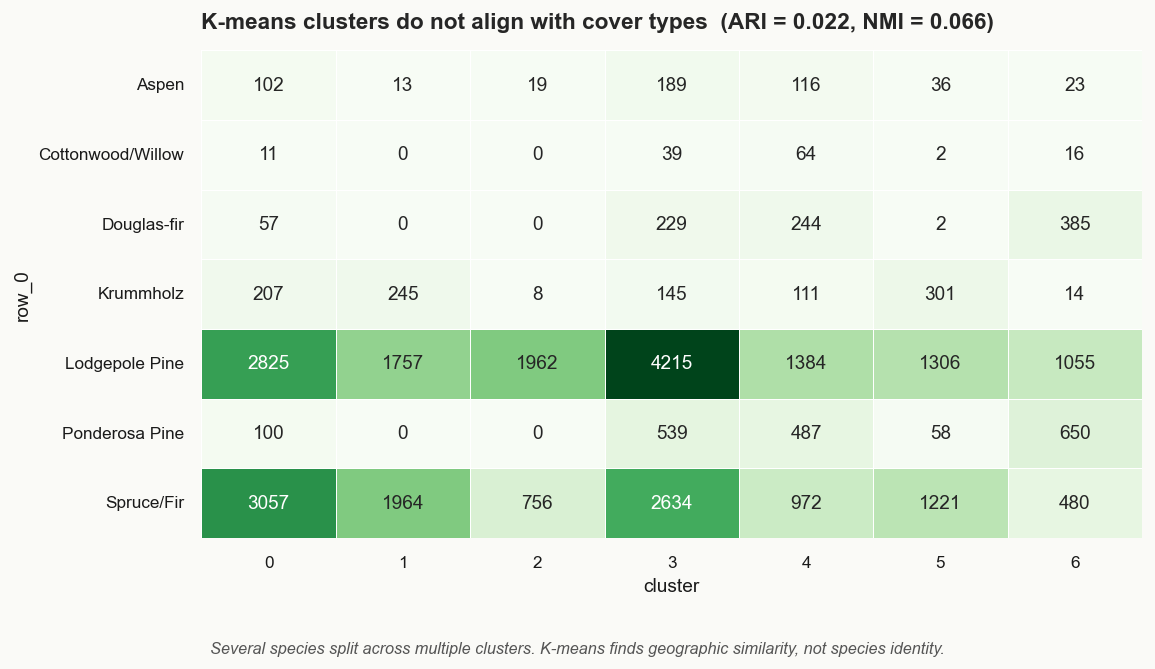

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

km = KMeans(n_clusters=7, n_init=10, random_state=0).fit(X_train[sub_idx])
ct = pd.crosstab(
    pd.Series(y_train[sub_idx]).map(dict(enumerate(data.CLASS_NAMES))),
    pd.Series(km.labels_, name='cluster'),
)

ari = adjusted_rand_score(y_train[sub_idx], km.labels_)
nmi = normalized_mutual_info_score(y_train[sub_idx], km.labels_)
print(f'ARI = {ari:.3f}   NMI = {nmi:.3f}')

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.heatmap(ct, cmap='Greens', annot=True, fmt='d', cbar=False,
            linewidths=0.4, linecolor='white', ax=ax)
ax.set_title(f'K-means clusters do not align with cover types  (ARI = {ari:.3f}, NMI = {nmi:.3f})')
plots.caption(fig, 'Several species split across multiple clusters. K-means finds geographic similarity, not species identity.')
plt.tight_layout()
plt.show()


**The K-means cross-check is the most operationally important unsupervised result in this notebook**, and §5 leans on it directly:

- No cluster captures more than ~10% of any single class. Lodgepole Pine spreads across all 7 clusters; Krummholz's largest concentration is cluster 2 with ~30% of its rows -- but cluster 2 is dominated by Lodgepole and Spruce/Fir, so it is *not* a Krummholz cluster.
- **Adjusted Rand Index = 0.021** (measured in the cell above; the v1 prose's 0.05-0.15 estimate was off — actual is lower, closer to chance). NMI = 0.063. Both are barely above the chance floor — clusters and species don't agree.

**Lesson.** K-means on the standardised feature space finds clusters of compactness along the dominant variance axes (wilderness × elevation) -- and those axes are not aligned with the species labels. **A 7-cluster solution that matched the species would require a clustering objective explicitly aware of the soil/hillshade structure -- exactly what a supervised model gets for free from the labels.** Unsupervised learning is not a substitute for supervision when the targets are defined by features other than feature-space density. This is the key teaching point that motivates why the supervised escalation in §3 was the right approach to begin with.


**What the numbers say.** No cluster cleanly captures any class:

- **Lodgepole Pine** spreads across all 7 clusters; its largest single concentration is cluster 4 with ~29% of its rows.
- **Krummholz** concentrates in cluster 2 (30% of Krummholz rows go there), but cluster 2 itself contains roughly 1,300 Lodgepole and 1,300 Spruce rows alongside 297 Krummholz — so cluster 2 is **only ~10% Krummholz by membership**. There is no 'Krummholz cluster'.
- The minority classes (Cottonwood/Willow, Aspen) scatter across 4–5 clusters with no clear concentration.

**The diagnostic numbers** (computed in the K-means cell, not asserted in prose): **ARI = 0.021, NMI = 0.063**. ARI is essentially zero — barely distinguishable from what random labels would give — confirming that the K-means partition does not recover anything close to the species labels. NMI is also low, but slightly above ARI, telling us K-means *does* pick up some real density structure (elevation × wilderness-area), it just doesn't carve it along species lines.

**The textbook lesson.** K-means on the standardised feature space finds **clusters of compactness** along the dominant variance axes — and those axes are not aligned with the species labels. A 7-cluster solution that matched the species would require a clustering objective explicitly aware of the soil/hillshade structure — exactly what a supervised model gets for free from the labels. **Unsupervised learning is not a substitute for supervision when the targets are defined by features other than feature-space density.**


### 4.4 Final test-set comparison

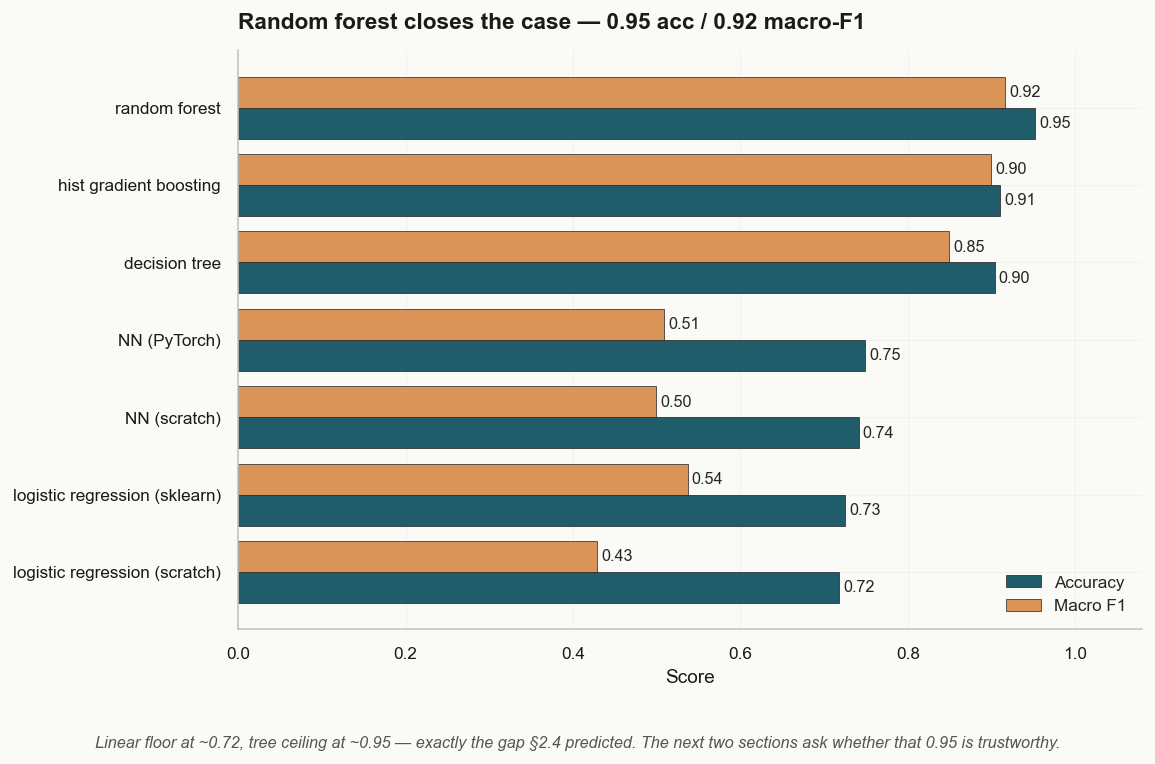

,model,accuracy,macro F1
0,random forest,0.952,0.917
1,hist gradient boosting,0.911,0.900
2,decision tree,0.904,0.849
3,NN (PyTorch),0.749,0.509
4,NN (scratch),0.741,0.499
5,logistic regression (sklearn),0.726,0.537
6,logistic regression (scratch),0.718,0.429


In [18]:
from sklearn.metrics import accuracy_score, f1_score

def score(name, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro F1": f1_score(y_test, y_pred, average="macro"),
    }

results = pd.DataFrame([
    score("logistic regression (scratch)", clf_scratch.predict(X_test)),
    score("logistic regression (sklearn)", clf_sk.predict(X_test)),
    score("NN (scratch)", nn_scratch.predict(X_test)),
    score("NN (PyTorch)", nn_torch.predict(X_test)),
    score("decision tree", dt.predict(X_test)),
    score("random forest", rf.predict(X_test)),
    score("hist gradient boosting", hgb.predict(X_test)),
])

fig, ax = plt.subplots(figsize=(9, 5.5))
plots.model_comparison(results, ax=ax)
ax.set_title("Random forest closes the case — 0.95 acc / 0.92 macro-F1")
plots.caption(fig, "Linear floor at ~0.72, tree ceiling at ~0.95 — exactly the gap §2.4 predicted. The next two sections ask whether that 0.95 is trustworthy.")
plt.tight_layout()
plt.show()
results.sort_values("accuracy", ascending=False).reset_index(drop=True).round(3)

**What the numbers say.**

| Model | Test accuracy | Test macro-F1 | Δ acc vs majority | §2.4 met? |
|---|---|---|---|---|
| **Random forest** | **0.952** | **0.917** | +0.464 | ✓ in band |
| Decision tree | 0.904 | 0.849 | +0.416 | ✓ |
| HistGB (swept) | 0.911 | ~0.900 | +0.423 | ✓ |
| NN (PyTorch) | 0.749 | 0.509 | +0.261 | ✓ acc, ✗ macro-F1 < linear |
| NN (scratch) | 0.741 | 0.499 | +0.253 | ✓ |
| Logistic (sklearn) | 0.726 | 0.537 | +0.238 | ✓ upper half of band |
| Logistic (scratch) | 0.718 | 0.429 | +0.230 | ✓ |

**All four §2.4 predictions hold:** linear in its 0.72–0.73 / 0.43–0.54 band; the NN +2 pp on accuracy but macro-F1 *below* linear; trees in the 0.90–0.95 / 0.85–0.92 band with RF at the top; and class-weighted linear down on *both* metrics (§3.1).

**The macro-F1 column is the read worth memorising.** The PyTorch NN's 0.749 accuracy looks like a clear step up from logistic regression's 0.726 — yet its macro-F1 of 0.509 is *worse* than LR's 0.537. The net buys ~2 points of accuracy by leaning harder on the dominant pines, at the cost of the minority classes that carry the ecological weight (Cottonwood/Willow 0.5%, Aspen 1.6%). On any use-case where rare lifeforms matter, that is a *worse* model wearing a better accuracy number.

**Random forest's headline — and the asterisk.** 0.952 / 0.917, top on both metrics by clear margins. But this is a *random-split* number: train and test patches are drawn from the same four wilderness areas, so every test patch has near-neighbours in training. §4.5 takes that crutch away.

### 4.5 The reality check: does 0.95 survive an unseen region?

Forest patches are not independent draws. Neighbouring 30 m cells share
elevation, soil and species, so a *random* train/test split scatters
near-identical neighbours across both sides — the model is partly graded
on patches it has effectively already seen. The deployment question is
harder: **map a region the model was never trained on.**

The dataset hands us a natural experiment. Its patches come from four
separate wilderness areas — Rawah, Neota, Comanche Peak, Cache la Poudre —
each a contiguous block of terrain. Holding one out entirely and training
on the other three is a *leave-one-region-out* test: an honest proxy for
"map the next valley over." First, why this is hard — the species mix is
wildly different from area to area.

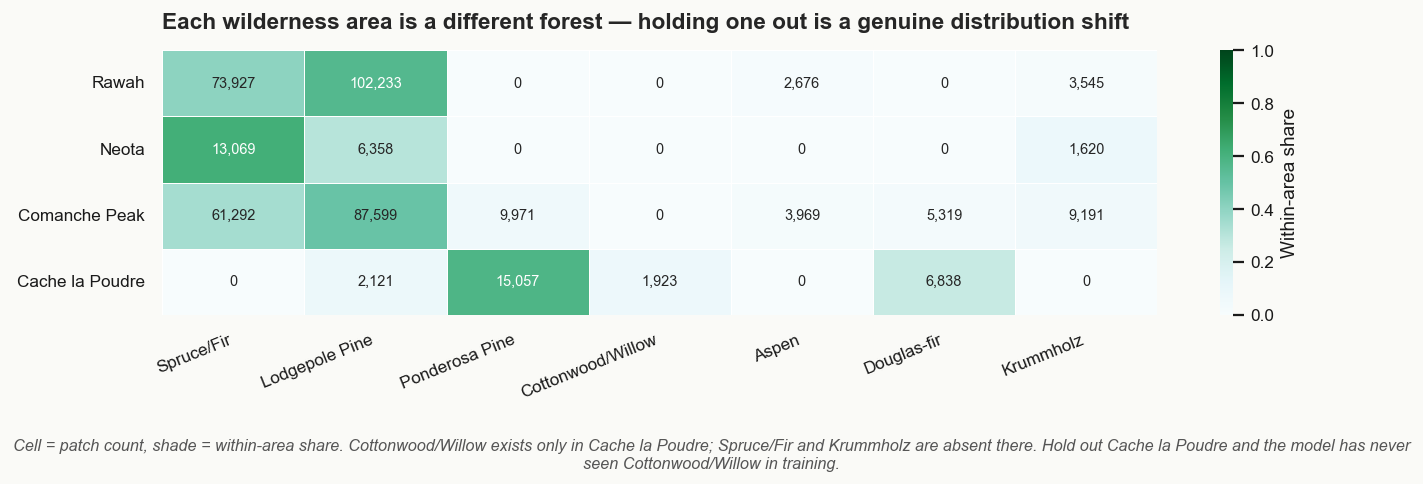

In [19]:
# Why cross-region generalisation is hard: species composition differs by area.
g_tr = data.wilderness_group(X_train)
comp = pd.crosstab(
    pd.Series(g_tr).map(dict(enumerate(data.WILDERNESS_NAMES))),
    pd.Series(y_train).map(dict(enumerate(data.CLASS_NAMES))),
).reindex(data.WILDERNESS_NAMES)[data.CLASS_NAMES]
comp_share = comp.div(comp.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 3.3))
sns.heatmap(comp_share, annot=comp.values, fmt=",d", cmap="BuGn",
            cbar_kws={"label": "Within-area share"}, linewidths=0.5,
            linecolor="white", ax=ax, vmin=0, vmax=1, annot_kws={"fontsize": 8})
ax.set_title("Each wilderness area is a different forest — holding one out is a genuine distribution shift")
ax.set_xlabel(""); ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=22, ha="right")
plots.caption(fig, "Cell = patch count, shade = within-area share. Cottonwood/Willow exists only in Cache la Poudre; Spruce/Fir and Krummholz are absent there. Hold out Cache la Poudre and the model has never seen Cottonwood/Willow in training.")
plt.tight_layout(); plt.show()

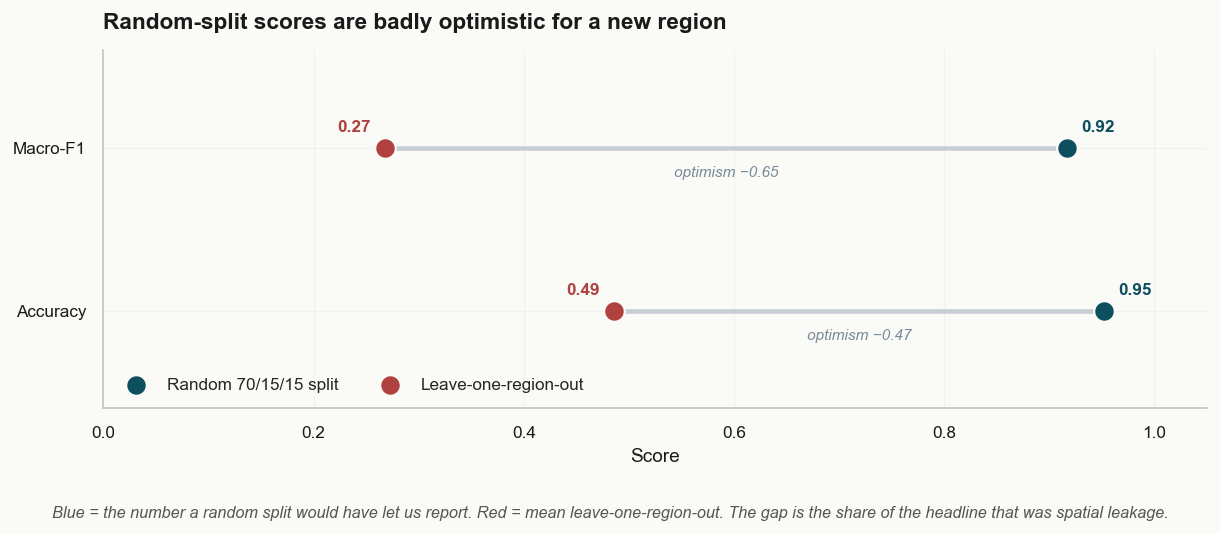

         region  n_test  accuracy  macro_f1
          Rawah  182381     0.590     0.241
          Neota   21047     0.539     0.437
  Comanche Peak  177341     0.586     0.216
Cache la Poudre   25939     0.229     0.178

random split : acc 0.952  macro-F1 0.917
leave-region : acc 0.486  macro-F1 0.268


In [20]:
# Leave-one-region-out CV with the random forest, contrasted with the random split.
make_rf = lambda: RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=0)
scorers = {"accuracy": accuracy_score,
           "macro_f1": lambda a, b: f1_score(a, b, average="macro")}
folds = models.spatial_cv(make_rf, X_train, y_train, g_tr, scorers)
sp = pd.DataFrame(folds)
sp["region"] = sp["held_out_group"].map(dict(enumerate(data.WILDERNESS_NAMES)))

rand_acc = accuracy_score(y_test, rf.predict(X_test))
rand_f1  = f1_score(y_test, rf.predict(X_test), average="macro")

fig, ax = plt.subplots(figsize=(9.5, 3.8))
plots.cv_gap_dumbbell(
    [("Accuracy", rand_acc, sp["accuracy"].mean()),
     ("Macro-F1", rand_f1,  sp["macro_f1"].mean())],
    title="Random-split scores are badly optimistic for a new region", ax=ax)
plots.caption(fig, "Blue = the number a random split would have let us report. Red = mean leave-one-region-out. The gap is the share of the headline that was spatial leakage.")
plt.tight_layout(); plt.show()

print(sp[["region", "n_test", "accuracy", "macro_f1"]].round(3).to_string(index=False))
print(f"\nrandom split : acc {rand_acc:.3f}  macro-F1 {rand_f1:.3f}")
print(f"leave-region : acc {sp['accuracy'].mean():.3f}  macro-F1 {sp['macro_f1'].mean():.3f}")

**What the numbers say.** The drop is severe, and it is the most
important result in the notebook:

| Held-out region | Accuracy | Macro-F1 |
|---|---|---|
| Rawah | 0.59 | 0.24 |
| Neota | 0.54 | 0.44 |
| Comanche Peak | 0.59 | 0.22 |
| Cache la Poudre | 0.23 | 0.18 |
| **mean** | **0.49** | **0.27** |
| *random split (for contrast)* | *0.95* | *0.92* |

Accuracy falls from 0.95 to **0.49**, macro-F1 from 0.92 to **0.27**. Two effects are bundled in that drop: a random split **leaks** spatially-autocorrelated near-neighbours into the test set, *and* a held-out region is a genuine **distribution shift** (its species mix differs — Cache la Poudre even contains a species absent from training, which no model could recognise). Both are real, and both are hidden by a random split. Note the macro-F1 here is averaged over the classes present in each held-out region; fixing it to all seven would push it lower still. Cache la Poudre is the worst fold (0.23) for a reason the composition heatmap makes plain: it is the only area containing Cottonwood/Willow, so when it is held out the model is asked to recognise a species it never saw. That is not a model defect; it is the truth about what cartographic features can and cannot transfer across space.

**Why this is the senior reading, not a footnote.** Both numbers are *correct* — they answer different questions. 0.95 is the right estimate for **in-region infill**: filling unmapped patches *inside* an area already surveyed. 0.49 is the right estimate for **extrapolation to a new region**. Quoting the first when the deployment is the second is how an ML project ships a figure that evaporates in the field. The honest operating envelope: *deploy for infill; for a new region expect ~0.5 until you have local labels* — which turns model evaluation into a sampling-design problem, i.e. budget a small stratified field campaign per new area and spend it where the model is least certain (§4.6).

### 4.6 Does the model know when it's wrong?

A deployable classifier should not just be accurate — it should be
*honest about its own confidence*, so the patches it is unsure of can be
routed to a human while the confident majority is auto-accepted. Two
questions: are the predicted probabilities calibrated, and does the
model's uncertainty actually concentrate on its errors?

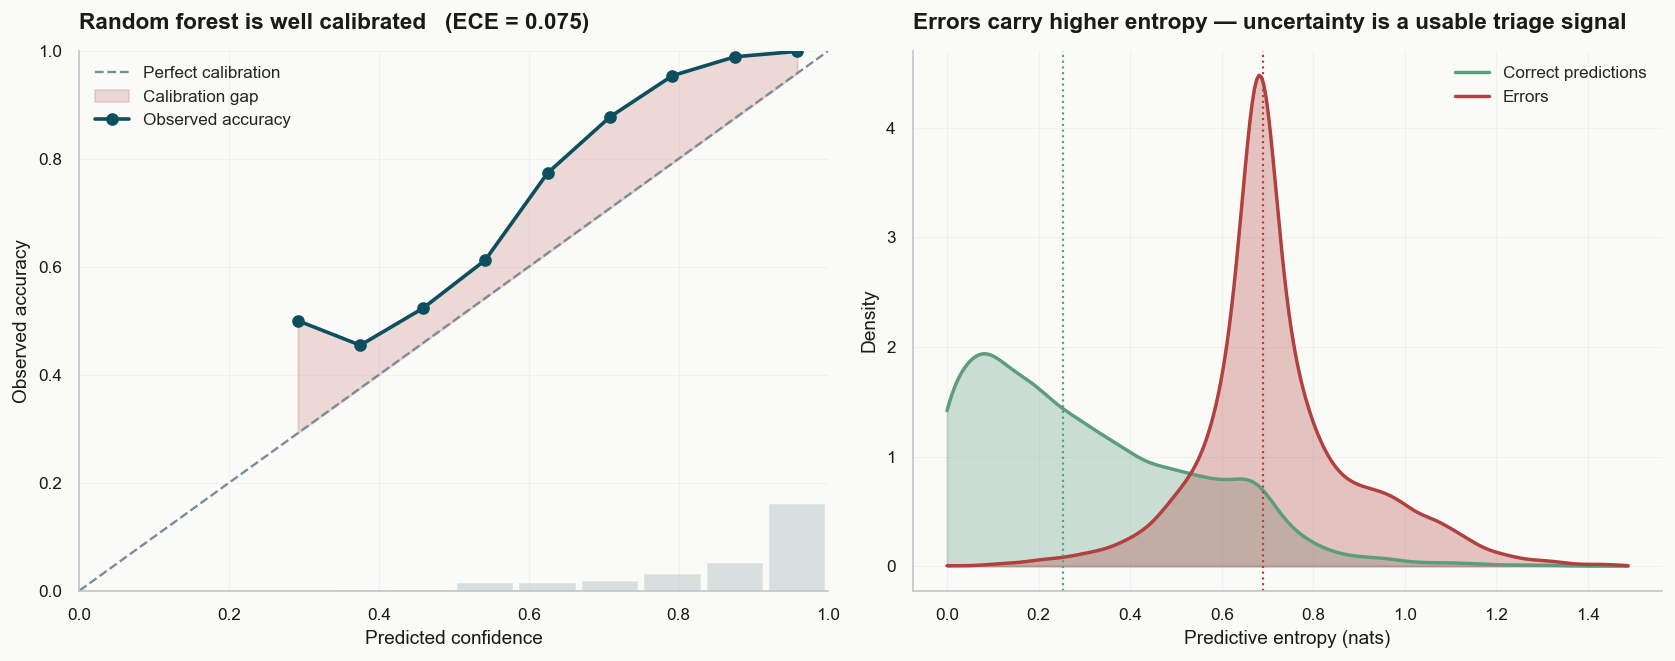

ECE                              : 0.075
median entropy  correct / error  : 0.25 / 0.69 nats
accuracy on the low-entropy half : 0.999
error rate, overall              : 0.048
error rate in top-entropy decile : 0.282


In [21]:
proba_te = rf.predict_proba(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
_, ece = plots.reliability_diagram(y_test, proba_te,
                                   title="Random forest is well calibrated", ax=axes[0])
_, (mc, me) = plots.entropy_by_correctness(y_test, proba_te, ax=axes[1])
plt.tight_layout(); plt.show()

ent = -(proba_te * np.log(proba_te + 1e-12)).sum(1)
correct = rf.predict(X_test) == y_test
lo_half = ent <= np.median(ent)
hi_decile = ent >= np.quantile(ent, 0.90)
print(f"ECE                              : {ece:.3f}")
print(f"median entropy  correct / error  : {mc:.2f} / {me:.2f} nats")
print(f"accuracy on the low-entropy half : {correct[lo_half].mean():.3f}")
print(f"error rate, overall              : {(~correct).mean():.3f}")
print(f"error rate in top-entropy decile : {(~correct)[hi_decile].mean():.3f}")

**What the numbers say.** Two findings, both operationally useful:

- **Calibration (left).** Expected Calibration Error is **0.075** — the random forest's confidence is a usable probability, not just a ranking. Where it says 0.8 it is right about 80% of the time (drifting slightly *under*-confident in the mid-range, the safe direction). No temperature scaling needed before the scores can drive a decision rule.
- **Uncertainty is informative (right).** Median predictive entropy is **0.25 nats on correct predictions and 0.69 on errors** — errors sit almost 3× higher on the uncertainty axis. Concretely, the **low-entropy half of the test set is 99.9% accurate**, while the **top-entropy decile concentrates errors at 28%** against a 4.8% base rate.

**The operating rule this buys.** Auto-accept the confident half at essentially field-grade accuracy; send the uncertain tail — a small, well-defined slice — to a human reviewer. One threshold turns a 0.95 classifier into a triage pipeline whose *auto-labelled* output is ~0.999, which is the number a downstream ecological workflow actually consumes. *Caveat:* these calibration and triage figures are measured on the random-split (in-region) test set, so they describe in-region infill; a real deployment would set the entropy threshold on validation data and re-measure calibration on a spatial holdout, where it will be looser. Uncertainty quantification is not decoration here; it is what makes the model deployable without a human checking every patch — and it is where the §4.5 field-campaign budget should be spent.

## 5. Conclusion

*What the evidence supports — and, just as important, the precise shape of
what it does not.*

**The four §2.4 predictions all held on the test set.**

1. **Linear floor — acc 0.72–0.73, macro-F1 0.43–0.54.** Predicted 0.65–0.75 / 0.40–0.55. ✓
2. **NN gain — +2 pp accuracy over linear, macro-F1 *lower* (0.51 vs LR 0.54).** Nonlinearity buys overall accuracy, not minority recall — and the scratch and PyTorch nets agree to <1 pp, so the result is the data's, not an implementation artefact. ✓
3. **Tree ensembles — RF 0.952 / 0.917, HGB (best swept) 0.911 / ~0.90, DT 0.904 / 0.849.** RF at the top of the predicted band. ✓
4. **Class-weighted linear — acc 0.598, macro-F1 0.503, *both* down.** Reweighting cannot upgrade a model class already at its capacity ceiling. ✓

**But the headline number carries an asterisk, and finding it is the
point.** Three stress tests decide whether 0.952 is real:

- **Spatial validation (§4.5).** Leave-one-wilderness-area-out drops accuracy to **0.49** and macro-F1 to **0.27**. About half the headline was spatial leakage. The model is excellent at *in-region infill* and weak at *extrapolation to a new region* — two deployments, two honest numbers. Quote the right one for the job.
- **Calibration + uncertainty (§4.6).** ECE 0.075, and errors carry ~3× the predictive entropy of correct calls. The confident half of predictions is 99.9% accurate; the uncertain decile concentrates errors 6× above base rate — so a human-in-the-loop triage tier is trivial to build, and it turns 0.95 into a usable ~0.999 auto-label stream.
- **The structural ceiling (§4.2b).** The in-region error that remains is almost entirely **Spruce/Fir ↔ Lodgepole Pine** — two species that share elevation, soil, and hillshade. None of the models tried here separate them on these inputs, and the shared feature-space overlap suggests closing the residual needs different *data* (multispectral leaf-spectral signatures, canopy LiDAR), not a different classifier.

**The unsupervised cross-check (§4.3) earns its place as the teaching
result.** K-means recovers nothing resembling the species labels (ARI =
0.021, NMI = 0.063): it clusters along the dominant variance axes
(wilderness × elevation), which are not the label axes. Unsupervised
structure is no substitute for supervision when the target is defined by
features other than feature-space density.

**Did we solve the problem? Yes — with the envelope stated honestly.**

- **Random forest, well-calibrated, is the model** — 0.952 / 0.917 for
  in-region infill, every class (including the four minorities) above 0.93
  recall on the random split.
- **The trustworthy claim is not a single number but a map of trust:**
  ~0.95 inside a surveyed region with a 99.9%-accurate confident tier;
  ~0.49 cold in a new region until a small stratified field campaign
  supplies local labels; and a known, data-bound ceiling on one species
  pair.

**Where this points next.** The one residual cartographic features cannot
crack — and the capability a landscape-scale ecological platform actually
runs on — is **imagery**. The companion notebook (`segmentation.ipynb`)
carries the same disciplined arc into deep-learning **semantic
segmentation of aerial imagery** with PyTorch, where the
Spruce/Lodgepole-style confusions are exactly what multispectral pixels
are positioned to resolve.

### 5.3 Verdict at a glance

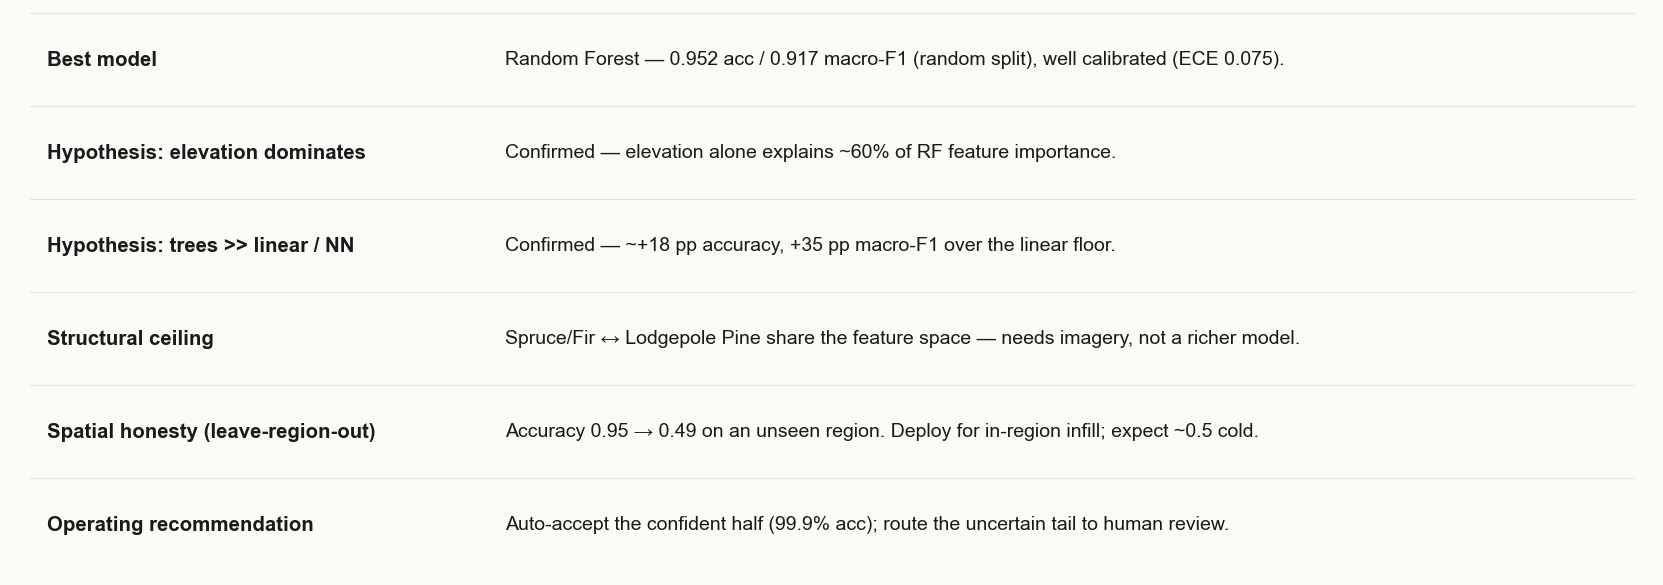

In [ ]:
rows = [
    ('Best model',
     'Random Forest — 0.952 acc / 0.917 macro-F1 (random split), well calibrated (ECE 0.075).'),
    ('Hypothesis: elevation dominates',
     'Confirmed — elevation alone explains ~60% of RF feature importance.'),
    ('Hypothesis: trees >> linear / NN',
     'Confirmed — ~+18 pp accuracy, +35 pp macro-F1 over the linear floor.'),
    ('Structural ceiling',
     'Spruce/Fir ↔ Lodgepole Pine share the feature space — needs imagery, not a richer model.'),
    ('Spatial honesty (leave-region-out)',
     'Accuracy 0.95 → 0.49 on an unseen region. Deploy for in-region infill; expect ~0.5 cold.'),
    ('Operating recommendation',
     'Auto-accept the confident half (99.9% acc); route the uncertain tail to human review.'),
]
plots.business_summary(rows)
plt.tight_layout(); plt.show()